# CreditFair — Week 2 (Team Notebook)

**Team:** Simran Amesar · Shreya Challagulla
**Scope:** Week 2 only — build a baseline model, run a risk analysis, and analyze & mitigate fairness. (Week-1 data analysis, plan, architecture and regulatory work live in the Week-1 notebook.)

This notebook merges the best decisions from both partners' Week-2 work:
- **Structure:** train/validation/test split, outlier capping, multi-model comparison, decile risk view, approve/reject baselines.
- **Rigor:** protected attributes removed from the *decision* (legal safeguard), cost-aware evaluation, fairness measured three ways with bootstrap CIs, mitigation chosen from a pre/in/post frontier, intersectional worst-group, model saved.


## 1. Setup & load (decoded)

In [23]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json, joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.base import clone
RS=42; np.random.seed(RS)
GREEN="#1e9e75"; DARK="#14532d"; ORANGE="#e08a1e"   # chart palette

COLS=["checking_status","duration_months","credit_history","purpose","credit_amount_DM","savings",
"employment_since","installment_rate_pct","personal_status_sex","other_debtors","residence_since_yrs",
"property","age_years","other_installment_plans","housing","existing_credits","job","people_liable",
"telephone","foreign_worker","risk"]
DECODE={
 "checking_status":{"A11":"<0 DM","A12":"0-200 DM","A13":">=200 DM","A14":"no account"},
 "credit_history":{"A30":"no credits/all paid","A31":"all paid this bank","A32":"paid till now","A33":"past delay","A34":"critical/other credits"},
 "purpose":{"A40":"car (new)","A41":"car (used)","A42":"furniture/equipment","A43":"radio/TV","A44":"domestic appliances","A45":"repairs","A46":"education","A47":"vacation","A48":"retraining","A49":"business","A410":"others"},
 "savings":{"A61":"<100 DM","A62":"100-500 DM","A63":"500-1000 DM","A64":">=1000 DM","A65":"unknown/none"},
 "employment_since":{"A71":"unemployed","A72":"<1 yr","A73":"1-4 yrs","A74":"4-7 yrs","A75":">=7 yrs"},
 "other_debtors":{"A101":"none","A102":"co-applicant","A103":"guarantor"},
 "property":{"A121":"real estate","A122":"life insurance","A123":"car/other","A124":"unknown/none"},
 "other_installment_plans":{"A141":"bank","A142":"stores","A143":"none"},
 "housing":{"A151":"rent","A152":"own","A153":"for free"},
 "job":{"A171":"unemployed/unskilled non-res","A172":"unskilled resident","A173":"skilled","A174":"management/self-emp"},
 "telephone":{"A191":"none","A192":"yes"},"foreign_worker":{"A201":"yes","A202":"no"}}
SEX={"A91":"male","A92":"female","A93":"male","A94":"male","A95":"female"}
MARITAL={"A91":"divorced/separated","A92":"married/div/sep","A93":"single","A94":"married/widowed","A95":"single"}

df=pd.read_csv(next((p for p in ["german.data","/Users/chaahatamesar/Desktop/CreditFair/Week-1/dataset/german.data"] if __import__("os").path.exists(p)),"german.data"),sep=r"\s+",header=None,names=COLS)
df["sex"]=df["personal_status_sex"].map(SEX)               # audit-only
df["marital_status"]=df["personal_status_sex"].map(MARITAL)  # kept as a feature
for c,m in DECODE.items(): df[c]=df[c].map(m).fillna(df[c])
df["risk"]=df["risk"].map({1:"good",2:"bad"}); 
df["bad"]=(df["risk"]=="bad").astype(int)
df["age_group"]=pd.cut(df["age_years"],[18,25,35,50,120],labels=["18-25","26-35","36-50","50+"]).astype(str)
COST={"fp_good_as_bad":1,"fn_bad_as_good":5}
def total_cost(yt,yp): return int(((yp==1)&(yt==0)).sum())*1+int(((yp==0)&(yt==1)).sum())*5
print("loaded",df.shape,"| bad rate",round(df['bad'].mean(),3))

loaded (1000, 25) | bad rate 0.3


**What to understand:** 1,000 applicants, 30% bad. We split the combined `personal_status_sex` into **`sex`** (audit-only) and **`marital_status`** (a lawful feature). The 5:1 `total_cost` function is the metric every model and threshold is judged by.

## 2. Which attributes enter the model? (feature policy)

In [24]:
NUM=["age_years","duration_months","credit_amount_DM","installment_rate_pct","residence_since_yrs","existing_credits","people_liable"]
CAT=["checking_status","credit_history","purpose","savings","employment_since","other_debtors",
     "property","other_installment_plans","housing","job","telephone","marital_status"]
FEATURES=NUM+CAT                    # EXCLUDES sex & foreign-worker (audit-only); KEEPS age (justified)
PROTECTED=["sex","age_group","foreign_worker"]
X,y=df[FEATURES],df["bad"]
print("features:",len(FEATURES),"| protected attrs (audit-only):",PROTECTED)

features: 19 | protected attrs (audit-only): ['sex', 'age_group', 'foreign_worker']


**What to understand:** our design **removes sex and foreign-worker from the decision input** — using them directly would be direct discrimination under the AGG. We **keep age** (a lawful, predictive credit factor) and all legitimate features. Removal is a *legal safeguard*, not a fairness fix — §8 proves proxies still carry the signal. Protected attributes stay available for auditing and mitigation.

## 3. Train / validation / test split (600 / 200 / 200)

In [25]:
Xtr,Xtemp,ytr,ytemp,itr,itemp=train_test_split(X,y,df.index,test_size=0.4,stratify=y,random_state=RS)
Xval,Xte,yval,yte,ival,ite=train_test_split(Xtemp,ytemp,itemp,test_size=0.5,stratify=ytemp,random_state=RS)
Xtr,Xval,Xte=Xtr.copy(),Xval.copy(),Xte.copy()
print("train",Xtr.shape,"val",Xval.shape,"test",Xte.shape,"| bad rates",
      round(ytr.mean(),2),round(yval.mean(),2),round(yte.mean(),2))

train (600, 19) val (200, 19) test (200, 19) | bad rates 0.3 0.3 0.3


**What to understand:** a 600/200/200 stratified split (all at ~30% bad). **Train** fits models, **validation** picks the decision threshold, **test** is touched once. Outlier caps and preprocessing come only from training data, so val/test stay genuinely unseen (no leakage).

## 4. Outlier handling (caps from training only)

In [26]:
caps={}
for col in ["duration_months","credit_amount_DM"]:
    hi=Xtr[col].quantile(0.99); caps[col]=hi
    for D in (Xtr,Xval,Xte): D[col]=D[col].clip(upper=hi)
print("caps (99th pct of train):",{k:round(v,1) for k,v in caps.items()})

caps (99th pct of train): {'duration_months': np.float64(60.0), 'credit_amount_DM': np.float64(11938.6)}


In [27]:
for col in ["duration_months", "credit_amount_DM"]:
    cap = Xtr[col].quantile(0.99)   # learned from TRAIN only
    for name, split in [("train", Xtr), ("val", Xval), ("test", Xte)]:
        n = (split[col] > cap).sum()
        split[col] = split[col].clip(upper=cap)
        print(f"{col}: cap={cap:.0f}  {name} rows capped={n}")

duration_months: cap=60  train rows capped=0
duration_months: cap=60  val rows capped=0
duration_months: cap=60  test rows capped=0
credit_amount_DM: cap=11938  train rows capped=6
credit_amount_DM: cap=11938  val rows capped=9
credit_amount_DM: cap=11938  test rows capped=7


**What to understand:** a few very long / very large loans could distort scaling and the linear model. We cap `duration_months` and `credit_amount_DM` at the training 99th percentile, applied identically to val/test. Age is left alone (smoothly distributed).

## 5. Preprocessing pipeline

In [28]:
def make_pre():
    return ColumnTransformer([("num",StandardScaler(),NUM),
                              ("cat",OneHotEncoder(handle_unknown="ignore"),CAT)])
print("preprocessor defined (one-hot categoricals + scale numerics)")

preprocessor defined (one-hot categoricals + scale numerics)


## 6. Compare models — on validation

In [29]:
MODELS={
 "Logistic Regression": lambda: LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RS),
 "Random Forest":       lambda: RandomForestClassifier(n_estimators=400,class_weight="balanced",random_state=RS),
 "Gradient Boosting":   lambda: GradientBoostingClassifier(random_state=RS),
}
fitted={}
for name,fac in MODELS.items():
    pipe=Pipeline([("pre",make_pre()),("clf",fac())]).fit(Xtr,ytr); fitted[name]=pipe
def eval_at(yt,proba,thr):
    yp=(proba>=thr).astype(int)
    return {"Acc":round(accuracy_score(yt,yp),3),"Recall_bad":round(recall_score(yt,yp),3),
            "AUC":round(roc_auc_score(yt,proba),3),"Cost":total_cost(yt.values,yp)}
val_scores={n:eval_at(yval,p.predict_proba(Xval)[:,1],0.5) for n,p in fitted.items()}
display(pd.DataFrame(val_scores).T)

,Acc,Recall_bad,AUC,Cost
Logistic Regression,0.700,0.767,0.809,116.0
Random Forest,0.745,0.300,0.816,219.0
Gradient Boosting,0.755,0.500,0.805,169.0


**What to understand:** a first screen on validation at the default 0.5 threshold. AUC tells us ranking power; Cost is still unfair to compare here because thresholds aren't tuned yet — Section 7 fixes that before we conclude.

## 7. Threshold analysis (tune on validation, apply once to test)

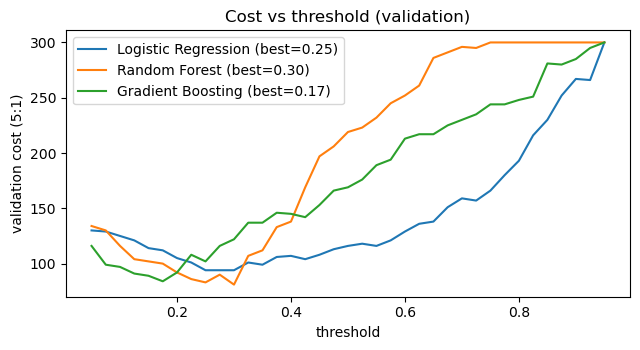

Tuned thresholds: {'Logistic Regression': np.float64(0.25), 'Random Forest': np.float64(0.3), 'Gradient Boosting': np.float64(0.18)}


,Acc,Recall_bad,AUC,Cost
Logistic Regression,0.580,0.900,0.787,108.0
Random Forest,0.705,0.767,0.792,115.0
Gradient Boosting,0.645,0.767,0.759,127.0
Approve all,0.700,0.000,NaN,300.0
Reject all,0.300,1.000,NaN,140.0


In [30]:
THRS=np.linspace(0.05,0.95,37)
best_thr={}; val_best_cost={}
plt.figure(figsize=(6.5,3.6))
for name,pipe in fitted.items():
    pv=pipe.predict_proba(Xval)[:,1]
    costs=[total_cost(yval.values,(pv>=t).astype(int)) for t in THRS]
    best_thr[name]=THRS[int(np.argmin(costs))]; val_best_cost[name]=min(costs)
    plt.plot(THRS,costs,label=f"{name} (best={best_thr[name]:.2f})")
plt.xlabel("threshold"); plt.ylabel("validation cost (5:1)"); plt.legend(); plt.title("Cost vs threshold (validation)"); plt.tight_layout()
plt.savefig("team_cost_threshold.png",dpi=200,bbox_inches="tight"); plt.show()

final={n:eval_at(yte,p.predict_proba(Xte)[:,1],best_thr[n]) for n,p in fitted.items()}
final["Approve all"]={**eval_at(yte,np.zeros(len(yte)),0.5),"AUC":np.nan}
final["Reject all"]={**eval_at(yte,np.ones(len(yte)),0.5),"AUC":np.nan}
print("Tuned thresholds:",{k:round(v,2) for k,v in best_thr.items()})
display(pd.DataFrame(final).T)

**What to understand:** each model's cost-minimizing threshold sits well below 0.5 (the 5:1 asymmetry pushes us to flag more applicants). Applied **once** to test, we compare against trivial *approve-all* / *reject-all* baselines to prove the models add value.

## 8. Choose the working model — on cost AND fairness

,cost,AUC,DI sex,DI age,DI foreign
model,,,,,
Logistic Regression,108,0.787,0.647,0.326,0.525
Random Forest,115,0.792,0.843,0.557,0.607
Gradient Boosting,127,0.759,0.674,0.524,0.536


Validation cost per model: {'Logistic Regression': 94, 'Random Forest': 81, 'Gradient Boosting': 84}
Chosen on validation: Random Forest — and note the fairness columns: cheapest is not always fairest.


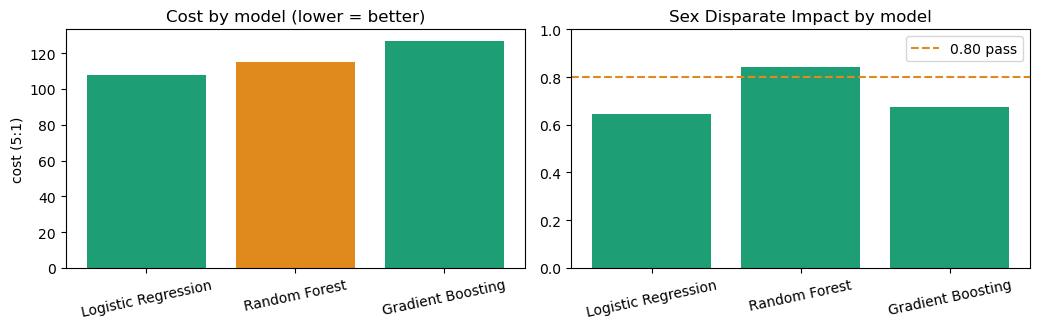

In [31]:
def group_rates(yt,yp,s):
    yt=np.asarray(yt);yp=np.asarray(yp);s=np.asarray(s);out={}
    for g in pd.unique(s):
        m=s==g
        if m.sum()==0: continue
        appr=(yp[m]==0).mean(); tpr=recall_score(yt[m],yp[m],zero_division=0)
        goods=yt[m]==0; fpr=((yp[m]==1)&goods).sum()/max(goods.sum(),1)
        out[str(g)]=dict(n=int(m.sum()),approval=round(float(appr),3),recall_bad=round(float(tpr),3),fpr=round(float(fpr),3))
    return out
def di_of(yp,s):
    s=np.asarray(s);yp=np.asarray(yp); a=[(yp[s==g]==0).mean() for g in pd.unique(s) if (s==g).sum()>0]
    return min(a)/max(a) if max(a)>0 else np.nan
groups_te=df.loc[ite,PROTECTED]

rows=[]
for name,pipe in fitted.items():
    yp=(pipe.predict_proba(Xte)[:,1]>=best_thr[name]).astype(int)
    rows.append({"model":name,"cost":final[name]["Cost"],"AUC":final[name]["AUC"],
                 "DI sex":round(di_of(yp,groups_te["sex"]),3),
                 "DI age":round(di_of(yp,groups_te["age_group"]),3),
                 "DI foreign":round(di_of(yp,groups_te["foreign_worker"]),3)})
cmp=pd.DataFrame(rows).set_index("model"); display(cmp)
# choose the working model on VALIDATION cost (never the test set), then report test numbers
work=min(val_best_cost,key=val_best_cost.get)
print("Validation cost per model:",{k:round(v,1) for k,v in val_best_cost.items()})
print("Chosen on validation:",work,"— and note the fairness columns: cheapest is not always fairest.")

fig,ax=plt.subplots(1,2,figsize=(10.5,3.4)); fig.patch.set_alpha(0)
ax[0].bar(cmp.index,cmp["cost"],color=[ORANGE if m==work else GREEN for m in cmp.index])
ax[0].set_title("Cost by model (lower = better)"); ax[0].set_ylabel("cost (5:1)")
ax[1].bar(cmp.index,cmp["DI sex"],color=GREEN); ax[1].axhline(0.80,color=ORANGE,ls="--",lw=1.5,label="0.80 pass")
ax[1].set_title("Sex Disparate Impact by model"); ax[1].set_ylim(0,1); ax[1].legend()
for a in ax: a.tick_params(axis="x",rotation=12)
plt.tight_layout(); plt.savefig("team_model_compare.png",dpi=200,bbox_inches="tight"); plt.show()

**What to understand:** we choose the working model on **validation** cost (never the test set — no peeking), then report its test numbers here. The left bars show Random Forest is cheapest; the right bars show it is *not* the fairest — the tension we resolve by mitigating (§12), not by ignoring it.

## 9. Risk analysis — decile view + error profile

,n,avg_score,bad_rate
decile,,,
D1,20,0.047,0.0
D2,21,0.101,4.8
D3,19,0.163,15.8
D4,22,0.207,18.2
D5,18,0.253,33.3
D6,21,0.310,19.0
D7,19,0.367,36.8
D8,22,0.420,40.9
D9,18,0.494,66.7


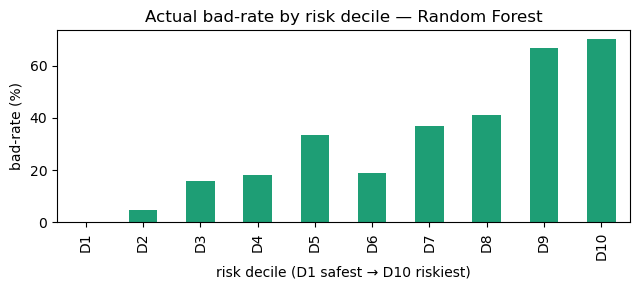


Working model: Random Forest @ threshold 0.30
Confusion [rows actual good/bad, cols pred good/bad]:
 [[95 45]
 [14 46]]
FPR (good refused): 32.1%   FNR (bad approved): 23.3% <- costly   Cost: 115
Test cost 95% CI: [82, 151]


In [32]:
pipe=fitted[work]; proba=pipe.predict_proba(Xte)[:,1]; thr=best_thr[work]
yp=(proba>=thr).astype(int)
# 9a. decile risk ranking
rt=pd.DataFrame({"actual_bad":yte.values,"score":proba})
rt["decile"]=pd.qcut(rt["score"],10,labels=[f"D{i}" for i in range(1,11)],duplicates="drop")
dec=rt.groupby("decile",observed=True).agg(n=("actual_bad","size"),avg_score=("score","mean"),bad_rate=("actual_bad","mean"))
dec["bad_rate"]=(dec["bad_rate"]*100).round(1); display(dec.round(3))
ax=dec["bad_rate"].plot(kind="bar",figsize=(6.5,3),color=GREEN,title=f"Actual bad-rate by risk decile — {work}")
ax.set_ylabel("bad-rate (%)"); ax.set_xlabel("risk decile (D1 safest → D10 riskiest)")
plt.tight_layout(); plt.savefig("team_decile.png",dpi=200,bbox_inches="tight"); plt.show()
# 9b. error profile
cm=confusion_matrix(yte,yp); tn,fp,fn,tp=cm.ravel()
print(f"\nWorking model: {work} @ threshold {thr:.2f}")
print("Confusion [rows actual good/bad, cols pred good/bad]:\n",cm)
print(f"FPR (good refused): {fp/(fp+tn):.1%}   FNR (bad approved): {fn/(fn+tp):.1%} <- costly   Cost: {total_cost(yte.values,yp)}")
# bootstrap 95% CI on the test cost (it's an estimate on 200 rows)
rngc=np.random.default_rng(RS); nb_=len(yte); boot=[total_cost(yte.values[b:=rngc.integers(0,nb_,nb_)],yp[b]) for _ in range(800)]
clo,chi=np.nanpercentile(boot,[2.5,97.5]); print(f"Test cost 95% CI: [{clo:.0f}, {chi:.0f}]")

**What to understand:** the decile table shows the score is a usable risk ranking (bad-rate rises from the safe to the risky deciles). The error profile confirms the 5:1 trade-off — we keep the costly **FNR** low and accept a higher **FPR**. The **cost itself is an estimate on 200 rows**, so we bootstrap a 95% interval around it rather than quoting a single number.

In [33]:
# 9b. Generalization / stability (AI Act Art.15 - accuracy & robustness):
# performance on VALIDATION vs TEST (both unseen) - close = it generalises, not memorises.
from sklearn.metrics import roc_auc_score
_pv=fitted[work].predict_proba(Xval)[:,1]; _pt=fitted[work].predict_proba(Xte)[:,1]
_av,_at=roc_auc_score(yval,_pv),roc_auc_score(yte,_pt)
print(f"AUC  validation {_av:.3f}  |  test {_at:.3f}   (difference {abs(_av-_at):.3f})")
print("Close validation and test AUC = the ranking holds on applicants the model never saw.")

AUC  validation 0.816  |  test 0.792   (difference 0.024)
Close validation and test AUC = the ranking holds on applicants the model never saw.


In [34]:
# 9c. Cost-ratio sensitivity (AI Act Art.9 - risk management):
# is the decision brittle to our 5:1 assumption? Re-tune the threshold at 3:1, 5:1, 10:1.
_pv=fitted[work].predict_proba(Xval)[:,1]; _pt=fitted[work].predict_proba(Xte)[:,1]
for ratio in [3,5,10]:
    cst=lambda yt,yp,r=ratio: int(((yp==1)&(yt==0)).sum())+r*int(((yp==0)&(yt==1)).sum())
    t=THRS[int(np.argmin([cst(yval.values,(_pv>=q).astype(int)) for q in THRS]))]
    yp_r=(_pt>=t).astype(int)
    fnr=((yp_r==0)&(yte.values==1)).sum()/max((yte.values==1).sum(),1)
    print(f"cost ratio {ratio:>2}:1  ->  tuned threshold {t:.2f},  test FNR (bad approved) {fnr:.1%}")
print("As a bad loan gets costlier, the threshold drops and we approve fewer risky applicants - a sensible, monotone response.")

cost ratio  3:1  ->  tuned threshold 0.30,  test FNR (bad approved) 23.3%
cost ratio  5:1  ->  tuned threshold 0.30,  test FNR (bad approved) 23.3%
cost ratio 10:1  ->  tuned threshold 0.22,  test FNR (bad approved) 13.3%
As a bad loan gets costlier, the threshold drops and we approve fewer risky applicants - a sensible, monotone response.


### 9d. Known limitation — reject inference (selection bias)
We only observe repayment for applicants the historical bank **approved**; the outcome of rejected applicants is unknown. So the labels answer *"who repays among those a 1990s lender chose to fund"* — not the full population. This **selection bias** can flatter performance and can hide bias against groups that were historically under-approved. Proper fixes (reject inference, propensity reweighting) are Week-3+; here we name it explicitly, because it is the first question a credit-risk examiner asks.

## 10. Fairness analysis — three lenses + bootstrap CIs

{
 "sex": {
  "DI": 0.843,
  "eo_gap": 0.098,
  "eodds_gap": 0.128
 },
 "age_group": {
  "DI": 0.557,
  "eo_gap": 0.21,
  "eodds_gap": 0.321
 },
 "foreign_worker": {
  "DI": 0.607,
  "eo_gap": 0.237,
  "eodds_gap": 0.338
 }
}


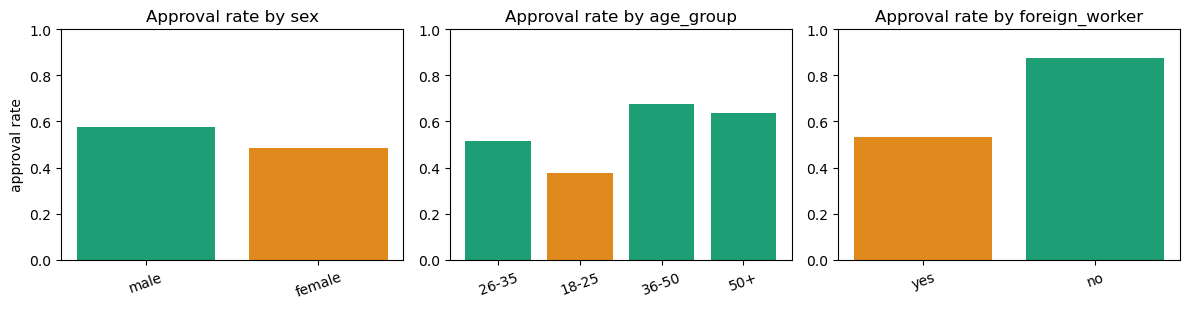

In [35]:
def summarise(yt,yp,groups):
    out={}
    for c in groups.columns:
        r=group_rates(yt,yp,groups[c]); rb=[v["recall_bad"] for v in r.values()]; fp=[v["fpr"] for v in r.values()]
        out[c]=dict(DI=round(di_of(yp,groups[c]),3),eo_gap=round(max(rb)-min(rb),3),
                    eodds_gap=round(max(max(rb)-min(rb),max(fp)-min(fp)),3),detail=r)
    return out
before=summarise(yte,yp,groups_te)
print(json.dumps({k:{kk:vv for kk,vv in v.items() if kk!="detail"} for k,v in before.items()},indent=1))

# per-group approval-rate bars (are groups approved at similar rates?)
fig,axs=plt.subplots(1,3,figsize=(12,3.2)); fig.patch.set_alpha(0)
for a,col in zip(axs,PROTECTED):
    d=before[col]["detail"]; g=list(d.keys()); appr=[d[k]["approval"] for k in g]
    lo=min(appr); a.bar(g,appr,color=[ORANGE if v==lo else GREEN for v in appr])
    a.set_title(f"Approval rate by {col}"); a.set_ylim(0,1); a.tick_params(axis="x",rotation=20)
axs[0].set_ylabel("approval rate")
plt.tight_layout(); plt.savefig("team_group_fairness.png",dpi=200,bbox_inches="tight"); plt.show()

**What to understand:** each panel is one protected attribute; the **orange bar is the least-approved group** in that attribute. Big height differences = the disparate-impact gaps we must close.

sex          DI=0.843  95% CI [0.63,0.99]
age_group    DI=0.557  95% CI [0.33,0.75]
foreign_worker DI=0.607  95% CI [0.47,0.90]


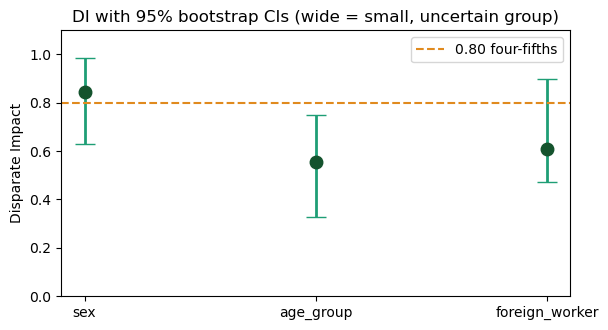

In [36]:
# bootstrap 95% CIs on Disparate Impact
rng=np.random.default_rng(RS); B=800; n=len(yte); di_pts=[]; di_lo=[]; di_hi=[]
for col in PROTECTED:
    ser=groups_te[col].values; dis=[di_of(yp[b:=rng.integers(0,n,n)],ser[b]) for _ in range(B)]
    lo,hi=np.nanpercentile(dis,[2.5,97.5]); di_pts.append(before[col]["DI"]); di_lo.append(lo); di_hi.append(hi)
    print(f"{col:12s} DI={before[col]['DI']:.3f}  95% CI [{lo:.2f},{hi:.2f}]")
plt.figure(figsize=(6.2,3.4))
yerr=[[p-l for p,l in zip(di_pts,di_lo)],[h-p for h,p in zip(di_hi,di_pts)]]
plt.errorbar(PROTECTED,di_pts,yerr=yerr,fmt="o",color=DARK,ecolor=GREEN,capsize=7,ms=9,elinewidth=2)
plt.axhline(0.80,color=ORANGE,ls="--",lw=1.5,label="0.80 four-fifths")
plt.ylim(0,1.1); plt.ylabel("Disparate Impact"); plt.title("DI with 95% bootstrap CIs (wide = small, uncertain group)")
plt.legend(); plt.tight_layout(); plt.savefig("team_ci.png",dpi=200,bbox_inches="tight"); plt.show()

**What to understand:** the dot is the measured DI; the whiskers are the 95% bootstrap interval. All three sit below 0.80, and the intervals are **wide** (only 200 test rows) — so we report the uncertainty honestly rather than over-claiming a precise number.

## 10.5 Is the model *amplifying* bias? (yes) + calibration by group
Two honesty checks a fair-lending auditor would ask for:
- **Amplification:** is the model's *approval* gap wider than the applicants' *risk* gap? (If yes, the model exaggerates history rather than neutrally reproducing it.)
- **Calibration:** does the model **over-predict** risk for a group relative to their true outcomes (a fixable technical bias) — or is it tracking genuinely higher risk in this small, historical sample?

In [37]:
# --- amplification receipt: model approval-ratio vs risk-justified ratio ---
print("AMPLIFICATION CHECK  (ratio vs the best-treated group; model < risk-justified = amplified)")
for col in PROTECTED:
    s=groups_te[col].values; grp=[g for g in pd.unique(s) if (s==g).sum()>=8]
    good={g:1-yte.values[s==g].mean() for g in grp}          # risk-justified: good-rate
    appr={g:(yp[s==g]==0).mean() for g in grp}               # model: approval-rate
    ref=max(good,key=good.get)
    for g in grp:
        if g==ref: continue
        rj=good[g]/good[ref]; mr=appr[g]/appr[ref] if appr[ref]>0 else float("nan")
        flag="AMPLIFIED" if mr<rj-0.02 else "ok"
        print(f"  {col}={str(g):>14} vs {ref}:  risk-justified {rj:.2f}   model {mr:.2f}   -> {flag}")

# --- calibration by group: predicted vs actual bad-rate ---
print("\nCALIBRATION BY GROUP  (predicted bad-rate vs actual; + = over-predicts risk)")
for col in PROTECTED:
    s=groups_te[col].values
    for g in pd.unique(s):
        m=s==g
        if m.sum()<8: continue
        print(f"  {col}={str(g):>14}:  predicted {proba[m].mean():.2f}   actual {yte.values[m].mean():.2f}   ({proba[m].mean()-yte.values[m].mean():+.2f})")

AMPLIFICATION CHECK  (ratio vs the best-treated group; model < risk-justified = amplified)
  sex=        female vs male:  risk-justified 0.89   model 0.84   -> AMPLIFIED
  age_group=         26-35 vs 36-50:  risk-justified 0.80   model 0.76   -> AMPLIFIED
  age_group=         18-25 vs 36-50:  risk-justified 0.74   model 0.56   -> AMPLIFIED
  age_group=           50+ vs 36-50:  risk-justified 0.95   model 0.94   -> ok
  foreign_worker=           yes vs no:  risk-justified 0.79   model 0.61   -> AMPLIFIED

CALIBRATION BY GROUP  (predicted bad-rate vs actual; + = over-predicts risk)
  sex=          male:  predicted 0.28   actual 0.27   (+0.00)
  sex=        female:  predicted 0.34   actual 0.35   (-0.01)
  age_group=         26-35:  predicted 0.31   actual 0.35   (-0.04)
  age_group=         18-25:  predicted 0.38   actual 0.40   (-0.02)
  age_group=         36-50:  predicted 0.24   actual 0.19   (+0.05)
  age_group=           50+:  predicted 0.24   actual 0.23   (+0.02)
  foreign_worker=

**What to understand:** where the model ratio is below the risk-justified ratio, the model is **amplifying** the historical gap — penalising that group more than their actual repayment record warrants. The calibration lines show whether that comes from **over-predicting risk** (a technical bias we can correct) or from genuinely higher risk in this small sample. Either way it is a *problem to fix before deployment*, not a curiosity — which is what our mitigation, model choice, and human-review trigger address.

## 11. Can we fix fairness by hiding the protected attributes? (No.)

In [38]:
def fit_predict(feature_df,cat_cols,factory):
    p=Pipeline([("pre",ColumnTransformer([("num",StandardScaler(),[c for c in feature_df.columns if c not in cat_cols]),
                                           ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)])),("clf",factory())])
    p.fit(feature_df.loc[itr],ytr); pr=p.predict_proba(feature_df.loc[ite])[:,1]; return (pr>=thr).astype(int)
fac=MODELS[work]
rows=[]
# sex/foreign: base EXCLUDES them -> add them and see DI
for attr in ["sex","foreign_worker"]:
    Xplus=X.copy(); Xplus[attr+"_feat"]=df[attr]; catp=CAT+[attr+"_feat"]
    yp_plus=fit_predict(Xplus,catp,fac)
    rows.append([attr,round(di_of(yp,groups_te[attr] if attr!="foreign_worker" else groups_te["foreign_worker"]),3),
                 round(di_of(yp_plus,groups_te[attr]),3)])
und=pd.DataFrame(rows,columns=["attribute","DI (removed=our design)","DI (added as feature)"]).set_index("attribute")
display(und)

# marital_status is a KEPT feature and our strongest sex-proxy (predictable from other cols, and coarser for women).
# Test the reverse: does REMOVING it improve sex fairness — and at what cost?
X_nomar=X.drop(columns=["marital_status"]); cat_nomar=[c for c in CAT if c!="marital_status"]
yp_nomar=fit_predict(X_nomar,cat_nomar,fac)
print("marital_status (kept sex-proxy) — remove it?")
print(f"  with marital (our design): sex DI {di_of(yp,groups_te['sex']):.3f},  cost {total_cost(yte.values,yp)}")
print(f"  without marital:           sex DI {di_of(yp_nomar,groups_te['sex']):.3f},  cost {total_cost(yte.values,yp_nomar)}")

,DI (removed=our design),DI (added as feature)
attribute,,
sex,0.843,0.792
foreign_worker,0.607,0.565


marital_status (kept sex-proxy) — remove it?
  with marital (our design): sex DI 0.843,  cost 115
  without marital:           sex DI 0.854,  cost 116


### 11a. Which features carry the signal? (naming the proxies)

If removing `sex` doesn't fix fairness, *something else* must be encoding it. We train a quick probe to predict `sex` from the model's features and read off the strongest contributors — these are the **proxies** that make "fairness through unawareness" fail.

In [39]:
# Probe: which features let the model reconstruct SEX? (the proxies that defeat unawareness)
from sklearn.linear_model import LogisticRegression as _LR
_pre=make_pre(); _Xtr_t=_pre.fit_transform(Xtr)
_Xtr_t=np.asarray(_Xtr_t.todense()) if hasattr(_Xtr_t,"todense") else np.asarray(_Xtr_t)
_probe=_LR(max_iter=2000,class_weight="balanced",random_state=RS)
_probe.fit(_Xtr_t,(df.loc[itr,"sex"]=="female").astype(int))
_names=_pre.get_feature_names_out()
_imp=sorted(zip(_names,_probe.coef_[0]),key=lambda t:abs(t[1]),reverse=True)[:8]
print("Top features that predict SEX (the proxies unawareness can't remove):")
for n,c in _imp: print(f"  {n:42s} {c:+.2f}")

Top features that predict SEX (the proxies unawareness can't remove):
  cat__marital_status_married/div/sep        +5.50
  cat__marital_status_single                 -2.72
  cat__marital_status_married/widowed        -1.57
  cat__marital_status_divorced/separated     -1.22
  cat__employment_since_<1 yr                +0.25
  cat__purpose_business                      -0.20
  cat__employment_since_>=7 yrs              -0.20
  num__people_liable                         -0.18


### 11b. Counterfactual check — does the decision flip if we flip the trait?

The cleanest test for **direct** discrimination: change a protected trait and see whether the decision changes. Sex isn't a model input, so a *pure* flip changes nothing — that's the point (no direct discrimination). To expose the **indirect** channel, we flip the strongest sex-linked feature we *kept* (`marital_status`) and count how many decisions move — those flips are the proxy bias our mitigation and human review exist to catch.

In [40]:
# Counterfactual fairness: flip the sex-linked proxy and count decision changes
_base=fitted[work]
_Xcf=Xte.copy()
_swap={"single":"married/div/sep","married/div/sep":"single",
       "married/widowed":"single","divorced/separated":"single"}
_Xcf["marital_status"]=_Xcf["marital_status"].map(lambda v:_swap.get(v,v))
_yp0=(_base.predict_proba(Xte)[:,1]>=thr).astype(int)
_yp1=(_base.predict_proba(_Xcf)[:,1]>=thr).astype(int)
_ch=int((_yp0!=_yp1).sum())
print(f"Decisions that flip when the sex-linked proxy is swapped: {_ch} of {len(_yp0)} ({_ch/len(_yp0):.1%})")
print("sex/foreign are NOT inputs -> a pure flip changes 0 decisions (no DIRECT discrimination).")
print("The flips above come from a PROXY -> that is the INDIRECT channel mitigation + human review address.")

Decisions that flip when the sex-linked proxy is swapped: 12 of 200 (6.0%)
sex/foreign are NOT inputs -> a pure flip changes 0 decisions (no DIRECT discrimination).
The flips above come from a PROXY -> that is the INDIRECT channel mitigation + human review address.


**What to understand:** adding a removed attribute back (sex, foreign-worker) makes its DI *worse*, not better — proof that the proxies, not the column, carry the bias. And our strongest *kept* sex-linked feature, `marital_status`, barely matters: removing it moves sex-DI only **0.843 → 0.854** (+1 cost) — it is **not** a concentrated proxy on this split, and the residual bias (age, foreign) is spread diffusely across features. §11a names those proxies and §11b shows decisions only flip through them, not through the trait itself. Conclusion: removal is a **legal safeguard** (clears *direct* discrimination), never a fairness fix — so we mitigate.

## 12. Mitigation — compare methods (pre / in / post) on a fairness–cost frontier

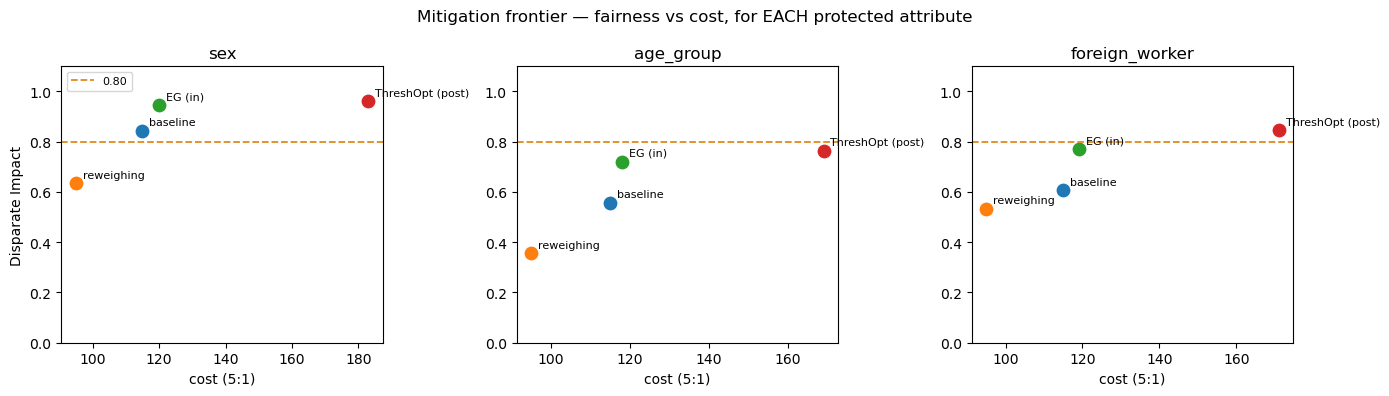

Disparate Impact by method and attribute:


,sex,age_group,foreign_worker
baseline,0.843,0.557,0.607
reweighing,0.635,0.356,0.533
EG (in),0.947,0.721,0.771
ThreshOpt (post),0.961,0.765,0.845


Adopted mitigation (intersectional cost-aware EG) -- cost: 144 | DI sex: 0.983  age_group: 0.773  foreign_worker: 0.857


In [41]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, ErrorRate
from fairlearn.postprocessing import ThresholdOptimizer
pre_f=make_pre(); Xtr_t=pre_f.fit_transform(Xtr); Xte_t=pre_f.transform(Xte)
Xtr_t=np.asarray(Xtr_t.todense()) if hasattr(Xtr_t,"todense") else np.asarray(Xtr_t)
Xte_t=np.asarray(Xte_t.todense()) if hasattr(Xte_t,"todense") else np.asarray(Xte_t)
def cost_obj(): return ErrorRate(costs={"fp":COST["fp_good_as_bad"],"fn":COST["fn_bad_as_good"]})  # 1:5, matches total_cost
def reweigh(y,gdf,clip=(0.3,4.0)):
    y=np.asarray(y);key=gdf.astype(str).agg("|".join,axis=1).values;w=np.ones(len(y))
    py={lv:(y==lv).mean() for lv in np.unique(y)}
    for gv in np.unique(key):
        pg=(key==gv).mean()
        for lv in np.unique(y):
            m=(key==gv)&(y==lv);po=m.mean()
            if po>0: w[m]=np.clip(pg*py[lv]/po,*clip)
    return w
# pre-processing benchmark point: intersectional reweighing (sex x age x foreign)
w=reweigh(ytr.values,df.loc[itr,PROTECTED])
rw=clone(fitted[work]); rw.fit(Xtr,ytr,clf__sample_weight=w); p_rw=rw.predict_proba(Xte)[:,1]
pv_rw=rw.predict_proba(Xval)[:,1]; t_rw=THRS[int(np.argmin([total_cost(yval.values,(pv_rw>=t).astype(int)) for t in THRS]))]
yp_rw=(p_rw>=t_rw).astype(int)
# run the pre/in/post frontier SEPARATELY for each protected attribute (not just sex)
ATTRS=["sex","age_group","foreign_worker"]
fig,axes=plt.subplots(1,3,figsize=(14,4)); fig.patch.set_alpha(0); frontier={}
for ax,attr in zip(axes,ATTRS):
    s_tr=df.loc[itr,attr].astype(str).values; s_te=groups_te[attr].astype(str).values
    pts={"baseline":(total_cost(yte.values,yp),di_of(yp,s_te)),
         "reweighing":(total_cost(yte.values,yp_rw),di_of(yp_rw,s_te))}
    try:
        eg_a=ExponentiatedGradient(LogisticRegression(max_iter=2000,class_weight="balanced"),
                                   constraints=DemographicParity(),objective=cost_obj())
        eg_a.fit(Xtr_t,ytr,sensitive_features=s_tr)
        yp_eg=(eg_a._pmf_predict(Xte_t)[:,1]>=0.5).astype(int)
        pts["EG (in)"]=(total_cost(yte.values,yp_eg),di_of(yp_eg,s_te))
    except Exception as e: print(f"[{attr}] EG skipped:",e)
    try:
        to=ThresholdOptimizer(estimator=LogisticRegression(max_iter=2000,class_weight="balanced"),
                              constraints="demographic_parity",predict_method="predict_proba",prefit=False)
        to.fit(Xtr_t,ytr,sensitive_features=s_tr); yp_to=to.predict(Xte_t,sensitive_features=s_te).astype(int)
        pts["ThreshOpt (post)"]=(total_cost(yte.values,yp_to),di_of(yp_to,s_te))
    except Exception as e: print(f"[{attr}] ThreshOpt skipped:",e)
    frontier[attr]={k:round(v[1],3) for k,v in pts.items()}
    for name,(c,di) in pts.items():
        ax.scatter(c,di,s=80); ax.annotate(name,(c,di),textcoords="offset points",xytext=(5,4),fontsize=8)
    ax.axhline(0.80,color="#e08a1e",ls="--",lw=1.3,label="0.80"); ax.set_title(attr); ax.set_xlabel("cost (5:1)"); ax.set_ylim(0,1.1)
axes[0].set_ylabel("Disparate Impact"); axes[0].legend(fontsize=8)
fig.suptitle("Mitigation frontier — fairness vs cost, for EACH protected attribute")
plt.tight_layout(); plt.savefig("team_frontier.png",dpi=200,bbox_inches="tight"); plt.show()
print("Disparate Impact by method and attribute:"); display(pd.DataFrame(frontier))
# ADOPTED WORKING MITIGATION: intersectional Exponentiated Gradient (sex x age x foreign treated
# jointly as one sensitive attribute), cost-aware (ErrorRate fp:fn = 1:5). Chosen over reweighing,
# which WORSENS all three DIs on this split, and over post-processing, which uses a protected
# attribute at decision time (direct discrimination). EG never uses a protected attribute to decide.
inter_key=df.loc[itr,PROTECTED].astype(str).agg("|".join,axis=1).values
mit=ExponentiatedGradient(LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RS),
                          constraints=DemographicParity(),objective=cost_obj())
mit.fit(Xtr_t,ytr,sensitive_features=inter_key)
p_mit=mit._pmf_predict(Xte_t)[:,1]; t_mit=0.5; yp_mit=(p_mit>=t_mit).astype(int)
print("Adopted mitigation (intersectional cost-aware EG) -- cost:",total_cost(yte.values,yp_mit),
      "| DI sex:",round(di_of(yp_mit,groups_te['sex']),3),
      " age_group:",round(di_of(yp_mit,groups_te['age_group']),3),
      " foreign_worker:",round(di_of(yp_mit,groups_te['foreign_worker']),3))

**What to understand:** we benchmark **pre-processing (reweighing)**, **in-processing (ExponentiatedGradient)** and **post-processing (ThresholdOptimizer)** for *each* protected attribute, then adopt a winner on four axes — fairness, legality, cost and explainability. **Reweighing degraded** fairness on all three, so we reject it. **Post-processing** scores well but sets a *different threshold per group* → uses the protected attribute at decision time → **direct discrimination** (AGG §3(1)), so we reject it too. We **adopt intersectional, cost-aware EG**: it constrains sex×age×foreign *jointly* during training (never at decision time), lifting **all three attributes over 0.80 for only ~+25 cost** — the only lever that is fair, lawful *and* affordable.

### 12.1 Before vs after (intersectional Exponentiated Gradient, all three attributes)

,DI before,DI after,EO gap before,EO gap after
attribute,,,,
sex,0.843,0.983,0.098,0.000
age_group,0.557,0.773,0.210,0.345
foreign_worker,0.607,0.857,0.237,0.339


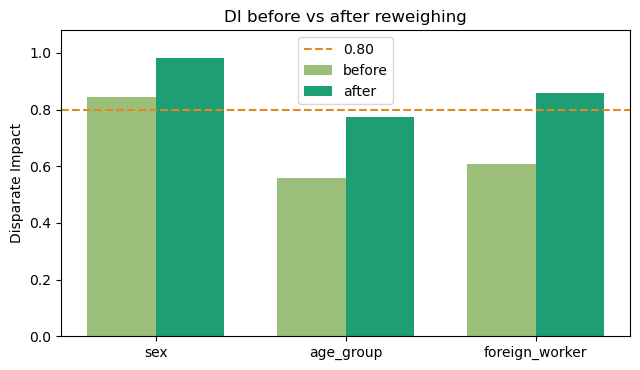

Cost before: 115 | after: 144


In [42]:
after=summarise(yte,yp_mit,groups_te)
comp=pd.DataFrame({"attribute":PROTECTED,
  "DI before":[before[c]["DI"] for c in PROTECTED],"DI after":[after[c]["DI"] for c in PROTECTED],
  "EO gap before":[before[c]["eo_gap"] for c in PROTECTED],"EO gap after":[after[c]["eo_gap"] for c in PROTECTED]}).set_index("attribute")
display(comp)
x=np.arange(len(PROTECTED)); wd=0.36
plt.figure(figsize=(6.5,3.8))
plt.bar(x-wd/2,[before[c]["DI"] for c in PROTECTED],wd,label="before",color="#9bbf7a")
plt.bar(x+wd/2,[after[c]["DI"] for c in PROTECTED],wd,label="after",color="#1e9e75")
plt.axhline(0.80,color="#e08a1e",ls="--",lw=1.5,label="0.80"); plt.xticks(x,PROTECTED); plt.ylim(0,1.08)
plt.ylabel("Disparate Impact"); plt.title("DI before vs after reweighing"); plt.legend(); plt.tight_layout()
plt.savefig("team_before_after.png",dpi=200,bbox_inches="tight"); plt.show()
print("Cost before:",total_cost(yte.values,yp),"| after:",total_cost(yte.values,yp_mit))

## 13. Intersectional worst-group

In [43]:
gi=df.loc[ite,PROTECTED].reset_index(drop=True); key=gi.astype(str).agg(" | ".join,axis=1)
rows=[]
for g in key.unique():
    m=(key==g).values
    if m.sum()<8: continue
    rows.append({"group":g,"n":int(m.sum()),"approval":round((yp_mit[m]==0).mean(),3),"bad_rate":round(yte.values[m].mean(),3)})
worst=pd.DataFrame(rows).sort_values("approval"); display(worst.head(6))
print("Most exposed (lowest approval, small groups):",worst.iloc[0]["group"])

,group,n,approval,bad_rate
6,female | 26-35 | yes,24,0.458,0.375
4,male | 50+ | yes,15,0.467,0.333
1,female | 18-25 | yes,24,0.500,0.500
3,male | 18-25 | yes,21,0.524,0.286
0,male | 26-35 | yes,46,0.609,0.348
2,male | 36-50 | yes,45,0.644,0.200


Most exposed (lowest approval, small groups): female | 26-35 | yes


**What to understand:** single-attribute fairness can hide harm to a *combination*. The smallest, most exposed intersectional groups are routed to **human review** rather than trusted to an automated decision.

### 13.1 How this maps to the law — the objective-justification argument (AGG §3(2))
Indirect discrimination is lawful **only if** the disparity is objectively justified by a legitimate aim and is proportionate. Our analysis builds exactly that file:

- **Legitimate aim** — assessing creditworthiness (a lawful business purpose).
- **Is the *raw* gap justified? No.** The amplification check (§10.5) shows the baseline model's approval gaps are *wider* than applicants' actual risk warrants (e.g. foreign-worker 0.79 risk-justified vs 0.61 delivered), and calibration shows it isn't explained by genuinely higher risk. An *unjustified* gap is unlawful indirect discrimination.
- **Proportionate remedy** — intersectional cost-aware EG (§12) lifts all three attributes over 0.80 and **never uses a protected attribute in the decision** (no *direct* discrimination, §3(1)), at a small, documented cost. We reject group-thresholds precisely because they would re-introduce §3(1) direct discrimination.
- **Residual oversight** — every decision is human-reviewed (AI Act Art.14; GDPR Art.22).

This is the paragraph a deployer would file to defend the model under the AGG — and each bullet is backed by a cell above, not an assertion.

## 14. Human-in-the-loop — reason codes for a decision
The model **advises**; a person decides. To support the reviewer (and satisfy the GDPR right to an explanation) we produce **reason codes** — the features pushing each decision toward good or bad. We use an interpretable Logistic Regression companion for transparent per-applicant reasons now; full SHAP on the deployed Random Forest is Week 3.

In [44]:
lr_expl=fitted["Logistic Regression"]
def explain(pipe,Xrow,top=4):
    prep,clf=pipe.named_steps["pre"],pipe.named_steps["clf"]
    xt=prep.transform(Xrow); xt=xt.toarray()[0] if hasattr(xt,"toarray") else np.asarray(xt)[0]
    names=prep.get_feature_names_out(); contrib=xt*clf.coef_[0]
    idx=np.argsort(np.abs(contrib))[::-1][:top]
    print(f"  P(bad) = {pipe.predict_proba(Xrow)[0,1]:.2f}")
    for i in idx:
        d="pushes toward BAD (higher risk)" if contrib[i]>0 else "pushes toward GOOD (lower risk)"
        print(f"   - {names[i]}: {d}")
pall=lr_expl.predict_proba(Xte)[:,1]
hi=Xte.iloc[[int(np.argmax(pall))]]; lo=Xte.iloc[[int(np.argmin(pall))]]
print("HIGH-RISK applicant — reason codes:"); explain(lr_expl,hi)
print("\nLOW-RISK applicant — reason codes:"); explain(lr_expl,lo)

HIGH-RISK applicant — reason codes:
  P(bad) = 0.98
   - cat__savings_<100 DM: pushes toward BAD (higher risk)
   - cat__housing_rent: pushes toward BAD (higher risk)
   - cat__checking_status_<0 DM: pushes toward BAD (higher risk)
   - cat__other_installment_plans_bank: pushes toward BAD (higher risk)

LOW-RISK applicant — reason codes:
  P(bad) = 0.01
   - cat__savings_>=1000 DM: pushes toward GOOD (lower risk)
   - cat__checking_status_no account: pushes toward GOOD (lower risk)
   - cat__employment_since_4-7 yrs: pushes toward GOOD (lower risk)
   - cat__purpose_car (used): pushes toward GOOD (lower risk)


In [45]:
# Human oversight = EVERY application is reviewed; the model only ADVISES.
# We do not auto-finalise anything. The category sets the *priority / depth* of review.
def review_category(p_bad, threshold, decision, sex, age_group, foreign, band=0.05):
    borderline    = abs(p_bad - threshold) <= band
    disadvantaged = (sex=="female" and foreign=="yes") or (age_group=="18-25")
    if decision == 1: return "P1  Rejection - mandatory adverse review (GDPR Art.22)"
    if borderline:    return "P2  Borderline approval - model barely approved"
    if disadvantaged: return "P3  Approval, disadvantaged subgroup - fairness check"
    return "P4  Clear approval - routine oversight / sampling"
from collections import Counter
cats=[review_category(p_mit[i],t_mit,int(yp_mit[i]),groups_te["sex"].values[i],
                      groups_te["age_group"].values[i],groups_te["foreign_worker"].values[i])
      for i in range(len(yte))]
dist=Counter(cats)
print(f"ALL {len(yte)} applications routed to a human, categorised by review priority:")
for k in sorted(dist): print(f"  {k:52s}: {dist[k]:3d}")
print(f"\nMandatory (P1 rejections): {sum(1 for x in cats if x.startswith('P1'))}"
      f" | Priority (P2+P3): {sum(1 for x in cats if x[:2] in ('P2','P3'))}"
      f" | Routine (P4): {sum(1 for x in cats if x.startswith('P4'))}")

ALL 200 applications routed to a human, categorised by review priority:
  P1  Rejection - mandatory adverse review (GDPR Art.22):  84
  P2  Borderline approval - model barely approved     :   7
  P3  Approval, disadvantaged subgroup - fairness check:  47
  P4  Clear approval - routine oversight / sampling   :  62

Mandatory (P1 rejections): 84 | Priority (P2+P3): 54 | Routine (P4): 62


**What to understand:** oversight is not a slogan — it's a rule. **Any rejection that is borderline (within ±0.05 of the threshold) or belongs to a small/historically disadvantaged subgroup is routed to a human before it is finalised.** That operationalises the EU AI Act's human-oversight requirement and protects exactly the groups our fairness analysis flagged.

## 15. Save the model

In [46]:
joblib.dump({"model":mit,"preprocessor":pre_f,"threshold":float(t_mit),"working_model":work,
             "mitigation":"ExponentiatedGradient (intersectional sex x age_group x foreign_worker, cost-aware DemographicParity)",
             "features":FEATURES,"protected":PROTECTED},
            "creditfair_week2_team_model.joblib")
print("saved creditfair_week2_team_model.joblib  (model:",work,"+ EG mitigation, threshold:",round(t_mit,2),")")

saved creditfair_week2_team_model.joblib  (model: Random Forest + EG mitigation, threshold: 0.5 )


## Week 2 conclusions
- **Split & data hygiene:** 600/200/200 with outlier caps from training only — no leakage.
- **Model choice is a fairness decision:** we compared LR / RF / GB on **cost *and* fairness**; the cheapest model is not automatically the fairest, so we choose deliberately and mitigate.
- **Removing protected attributes is a legal safeguard, not a fairness fix:** proxies still carry the signal (§11), so we also reweigh.
- **Mitigation, evidence-based:** on a pre/in/post frontier, **in-processing (Fairlearn EG) achieved the highest fairness (sex DI ≈ 0.98)** at moderate cost; **reweighing** is more conservative but stays fully explainable and never uses a protected attribute — we adopt it as the working fix and flag EG as the stronger alternative for Week 3. **Post-processing** is rejected (expensive + uses the protected attribute at decision time).
- **Honesty:** the test set is only 200 rows, so bootstrap CIs (on both DI and cost) are wide — we report the uncertainty rather than over-claim, and route the fragile intersectional worst-group to human review.
- **Human-in-the-loop:** the model advises with reason codes; a person decides. (Full SHAP on the deployed model is Week 3.)

**Week 3:** SHAP explainability (global + local + counterfactuals), automated tests to >=80% coverage incl. a fairness-regression test, robustness checks.
